In [1]:
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
)

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load Metadata
train_dir = "train"
test_dir = "test"

train_meta = pd.read_csv(os.path.join(train_dir, "train_metadata.csv"))
test_meta = pd.read_csv(os.path.join(test_dir, "test_metadata.csv"))

# Load and Combine Features
def load_features(base_dir):
    color = pd.read_csv(os.path.join(base_dir, "Features/color_histogram.csv"))
    hog = pd.read_csv(os.path.join(base_dir, "Features/hog_pca.csv"))
    additional = pd.read_csv(os.path.join(base_dir, "Features/additional_features.csv"))

    for df in [color, hog, additional]:
        for col in df.columns:
            if df[col].dtype == 'object':
                df.drop(columns=col, inplace=True)

    combined = pd.concat([color, hog, additional], axis=1)
    return combined

X_train = load_features(train_dir)
X_test = load_features(test_dir)
y_train = train_meta['ClassId']


In [3]:
# Imputation and Standardization
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)


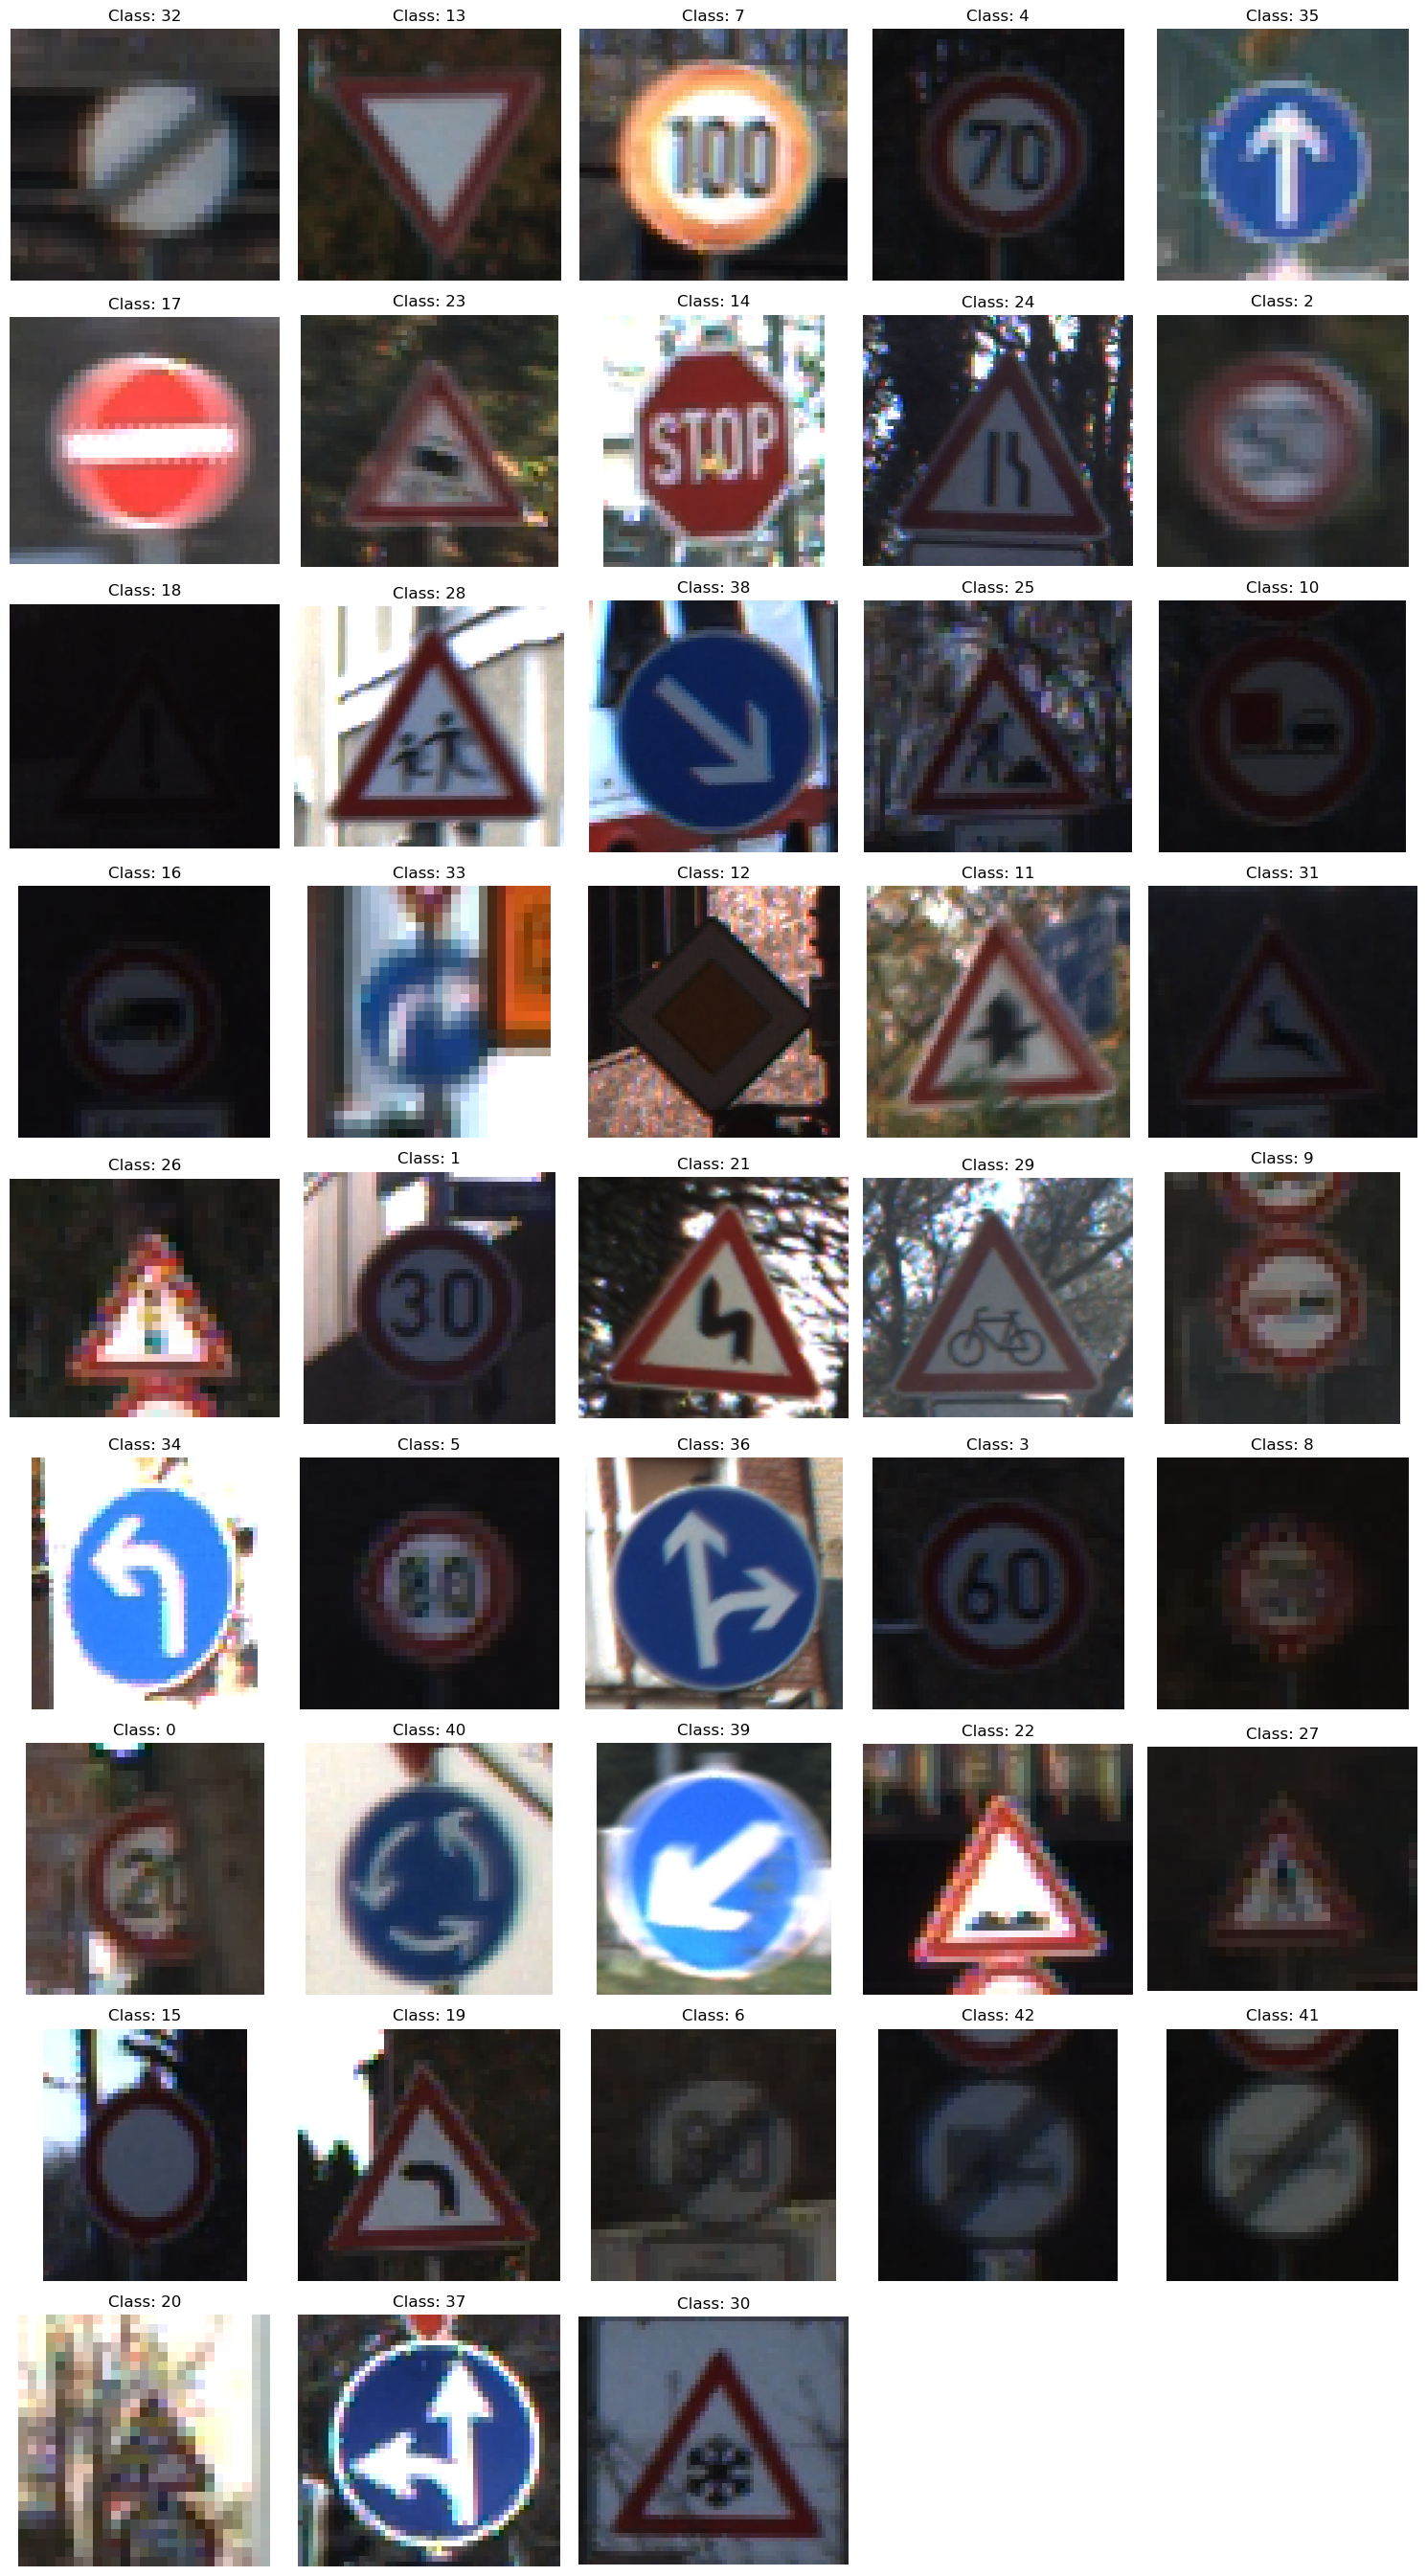

In [4]:
# Get the sample image paths (one from each class)
sample_paths = train_meta.groupby('ClassId').head(1)['image_path']

# Define the number of images per row
num_images = len(sample_paths)
cols = 5  # Number of images per row
rows = (num_images // cols) + (1 if num_images % cols != 0 else 0)  # Calculate number of rows needed

# Create a figure with subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))

# Flatten axes array to make indexing easier
axes = axes.flatten()

# Loop through the sample images and display them
for i, path in enumerate(sample_paths):
    img = plt.imread(os.path.join(train_dir, path))
    axes[i].imshow(img)
    axes[i].set_title(f"Class: {train_meta[train_meta['image_path'] == path]['ClassId'].values[0]}")
    axes[i].axis('off')

# Hide any unused subplots
for i in range(num_images, len(axes)):
    axes[i].axis('off')

plt.tight_layout()  # Adjust the layout for better spacing
plt.show()


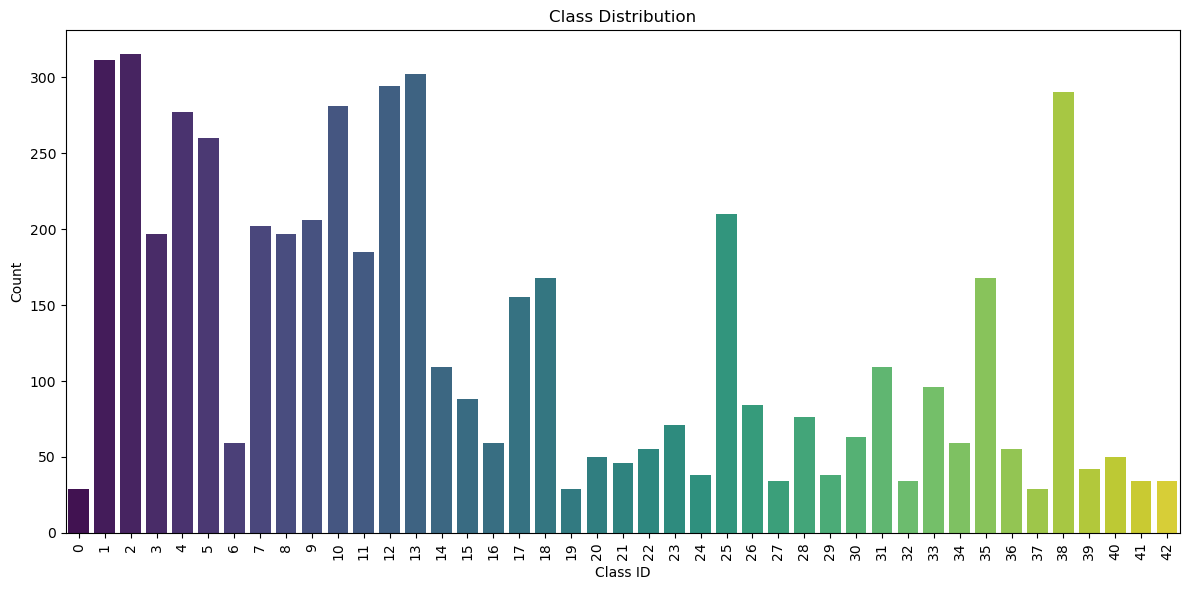

In [5]:
# Class distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=train_meta, x='ClassId', palette='viridis')
plt.title("Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
scores = cross_val_score(rf_model, X_train_preprocessed, y_train, cv=5, scoring='accuracy')
print("Random Forest CV Accuracy:", scores.mean())


Random Forest CV Accuracy: 0.7889939942183767


In [7]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
scores = cross_val_score(svm_model, X_train_preprocessed, y_train, cv=5, scoring='accuracy')
print("SVM CV Accuracy:", scores.mean())


SVM CV Accuracy: 0.7392474591243215


In [8]:
# Fit model
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_preprocessed, y_train, test_size=0.2, random_state=42)

best_model = RandomForestClassifier(n_estimators=100).fit(X_train_split, y_train_split)
y_pred = best_model.predict(X_val)

In [9]:
# Print classification report
print("Classification Report:")
print(classification_report(y_val, y_pred))

# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(20))
plt.title('Top 20 Most Important Features')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.close()

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.close()

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.44      0.62         9
           1       0.65      0.84      0.74        58
           2       0.68      0.77      0.72        61
           3       0.70      0.70      0.70        37
           4       0.73      0.67      0.70        54
           5       0.69      0.63      0.66        52
           6       1.00      0.91      0.95        11
           7       0.82      0.74      0.78        42
           8       0.67      0.76      0.71        29
           9       0.74      0.85      0.80        41
          10       0.71      0.81      0.76        54
          11       0.48      0.70      0.57        37
          12       1.00      1.00      1.00        55
          13       1.00      1.00      1.00        60
          14       0.96      0.96      0.96        24
          15       0.80      0.44      0.57        18
          16       1.00      0.91      0.95        11
    

Error Analysis

In [10]:
# Get misclassified samples
misclassified_indices = np.where(y_val != y_pred)[0]
misclassified_true = y_val.iloc[misclassified_indices]
misclassified_pred = y_pred[misclassified_indices]

# Create error analysis dataframe
error_df = pd.DataFrame({
    'True_Class': misclassified_true,
    'Predicted_Class': misclassified_pred
})

# Count misclassification patterns
error_patterns = error_df.groupby(['True_Class', 'Predicted_Class']).size().reset_index(name='count')
error_patterns = error_patterns.sort_values('count', ascending=False)

# Visualize most common misclassification patterns
plt.figure(figsize=(12, 6))
top_errors = error_patterns.head(10)
sns.barplot(x='count', y='True_Class', hue='Predicted_Class', data=top_errors)
plt.title('Top 10 Most Common Misclassification Patterns')
plt.xlabel('Number of Misclassifications')
plt.ylabel('True Class')
plt.tight_layout()
plt.savefig('error_patterns.png')
plt.close()

# Analyze feature distributions for misclassified samples
misclassified_features = X_train.iloc[misclassified_indices]
correct_features = X_train.iloc[~X_train.index.isin(misclassified_indices)]

# Compare distributions of top 5 important features for correct vs misclassified samples
top_features = feature_importance['feature'].head(5).tolist()

plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=correct_features[feature], label='Correctly Classified', alpha=0.5)
    sns.kdeplot(data=misclassified_features[feature], label='Misclassified', alpha=0.5)
    plt.title(f'Distribution of {feature}')
    plt.legend()
plt.tight_layout()
plt.savefig('feature_distributions.png')
plt.close()

Learning curves to analyze how the model's performance changes with different training set sizes

In [11]:
# Learning Curves Analysis
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                       n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes,
        scoring='accuracy')
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid()
    
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    
    plt.legend(loc="best")
    plt.tight_layout()
    return plt

# Plot learning curves for Random Forest
rf_learning_curve = plot_learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    "Learning Curves (Random Forest)",
    X_train_preprocessed, y_train,
    cv=5, n_jobs=-1
)
rf_learning_curve.savefig('rf_learning_curves.png')
plt.close()

# Plot learning curves for SVM
svm_learning_curve = plot_learning_curve(
    SVC(kernel='rbf', C=1, gamma='scale', random_state=42),
    "Learning Curves (SVM)",
    X_train_preprocessed, y_train,
    cv=5, n_jobs=-1
)
svm_learning_curve.savefig('svm_learning_curves.png')
plt.close()

In [12]:
# Choose Random Forest as the final model for prediction
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train_preprocessed, y_train)

y_test_pred = final_model.predict(X_test_preprocessed)

# Add prediction to submission.csv
submission = test_meta.copy()
submission['ClassId'] = y_test_pred
submission[['id', 'ClassId']].to_csv("submission.csv", index=False)


In [13]:
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model


Try to improve the model performance by adopting CNN feature extractor

In [14]:
# CNN Feature Extractor ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
model = Model(inputs=base_model.input, outputs=base_model.output)

def extract_deep_feature(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = preprocess_input(np.expand_dims(x, axis=0))
    feature = model.predict(x, verbose=0)
    return feature.flatten()

# Extract features
def build_feature_df(meta_df, folder):
    image_paths = meta_df["image_path"].tolist()
    full_paths = [os.path.join(folder, path) for path in image_paths]
    
    features = []
    for p in tqdm(full_paths, desc=f"Extracting features from {folder}"):
        features.append(extract_deep_feature(p))

    features_df = pd.DataFrame(features)
    features_df.insert(0, "image_path", meta_df["image_path"].values)
    return features_df

train_feat = build_feature_df(train_meta, train_dir)
test_feat  = build_feature_df(test_meta , test_dir)

# Merge features with metadata
train_full = train_meta[["image_path"]].merge(train_feat, on="image_path", how="left")
test_full  = test_meta [["image_path"]].merge(test_feat , on="image_path", how="left")

assert train_full.isna().sum().sum() == 0, "Missing features in training merge."
assert test_full .isna().sum().sum() == 0, "Missing features in test merge."



Extracting features from test: 100%|█████████████████████████████| 2353/2353 [02:18<00:00, 17.02it/s]


In [15]:
# Design metrics
X_train = train_full.drop(columns=["image_path"])
y_train = train_meta["ClassId"]

X_test  = test_full.drop(columns=["image_path"])

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [16]:
# Model selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf  = RandomForestClassifier(random_state=42)
et  = ExtraTreesClassifier  (random_state=42)
svm = SVC(kernel="rbf", probability=True, random_state=42)
xgb = XGBClassifier(eval_metric="mlogloss", random_state=42)

In [17]:
# Evaluate individual models
models = {
    'Random Forest': rf,
    'Extra Trees': et,
    'SVM': svm,
    'XGBoost': xgb
}

print("\nIndividual Model Performance:")
print("-" * 50)
for name, model in models.items():
    # Cross-validation scores
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    print(f"{name}:")
    print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    # Train on full dataset and evaluate
    model.fit(X_train_scaled, y_train)
    train_pred = model.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, train_pred)
    print(f"  Training Accuracy: {train_acc:.4f}")
    print("-" * 50)



Individual Model Performance:
--------------------------------------------------
Random Forest:
  CV Accuracy: 0.7340 (+/- 0.0083)
  Training Accuracy: 1.0000
--------------------------------------------------
Extra Trees:
  CV Accuracy: 0.7555 (+/- 0.0117)
  Training Accuracy: 1.0000
--------------------------------------------------
SVM:
  CV Accuracy: 0.8216 (+/- 0.0089)
  Training Accuracy: 0.9690
--------------------------------------------------
XGBoost:
  CV Accuracy: 0.7664 (+/- 0.0290)
  Training Accuracy: 1.0000
--------------------------------------------------


In [18]:
# Ensemble model
param_grid = {
    "rf__n_estimators": [200],
    "et__n_estimators": [200],
    "svm__C": [1],
    "xgb__max_depth": [6]
}

ensemble = VotingClassifier(
    estimators=[("rf", rf), ("et", et), ("svm", svm), ("xgb", xgb)],
    voting="soft"
)

grid = GridSearchCV(ensemble, param_grid, cv=cv, scoring="accuracy",
                   n_jobs=-1, refit=True, verbose=2)
grid.fit(X_train_scaled, y_train)

print("CV best-mean-accuracy:", grid.best_score_)
print("Best params:", grid.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END et__n_estimators=200, rf__n_estimators=200, svm__C=1, xgb__max_depth=6; total time= 7.9min
[CV] END et__n_estimators=200, rf__n_estimators=200, svm__C=1, xgb__max_depth=6; total time= 8.0min
[CV] END et__n_estimators=200, rf__n_estimators=200, svm__C=1, xgb__max_depth=6; total time= 8.0min
[CV] END et__n_estimators=200, rf__n_estimators=200, svm__C=1, xgb__max_depth=6; total time= 8.0min
[CV] END et__n_estimators=200, rf__n_estimators=200, svm__C=1, xgb__max_depth=6; total time= 8.0min
CV best-mean-accuracy: 0.8290804695036803
Best params: {'et__n_estimators': 200, 'rf__n_estimators': 200, 'svm__C': 1, 'xgb__max_depth': 6}


In [19]:
# Choose the best model and predict on test cases
best_model = grid.best_estimator_
best_model.fit(X_train_scaled, y_train)

y_pred_train = best_model.predict(X_train_scaled)
print("Re-substituted train accuracy:", accuracy_score(y_train, y_pred_train))


Re-substituted train accuracy: 1.0


In [20]:
# Additional evaluation metrics
print("Classification Report:")
print(classification_report(y_train, y_pred_train))

# Confusion Matrix
cm = confusion_matrix(y_train, y_pred_train)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png')
plt.close()

test_pred = best_model.predict(X_test_scaled)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00       311
           2       1.00      1.00      1.00       315
           3       1.00      1.00      1.00       197
           4       1.00      1.00      1.00       277
           5       1.00      1.00      1.00       260
           6       1.00      1.00      1.00        59
           7       1.00      1.00      1.00       202
           8       1.00      1.00      1.00       197
           9       1.00      1.00      1.00       206
          10       1.00      1.00      1.00       281
          11       1.00      1.00      1.00       185
          12       1.00      1.00      1.00       294
          13       1.00      1.00      1.00       302
          14       1.00      1.00      1.00       109
          15       1.00      1.00      1.00        88
          16       1.00      1.00      1.00        59
    

In [21]:
# Save the labelled file to submission.csv
submission = pd.DataFrame({
    "id":      test_meta["id"], 
    "ClassId": test_pred
})
submission.to_csv("submission.csv", index=False)
print("submission.csv written.")


submission.csv written.
